# Session 1 Introduction: Maya's First Portfolio

Maya Chen is a Portfolio Manager at Lindenfield Wealth Partners, a fictional mid-size Registered Investment Adviser used throughout the course. Her firm just rolled out an intake tool powered by artificial intelligence: a client answers a short questionnaire, the agent sorts them into one of five risk-character archetypes, and a minimum-variance allocation lands in four minutes.

A Balanced-archetype client came in today. The Balanced archetype is the middle-of-the-road profile in Lindenfield's library: a diversified equity portfolio of about twenty-two names spread evenly across the eleven sectors of the market, meant for clients who accept moderate swings in return for long-term compounding. She came in with a hundred-thousand-dollar budget, a three-to-ten year horizon, and a twenty-percent concentration cap. The agent produced the allocation shown below. Maya's boss Lou asks the only question that matters: is this actually a good idea?

By the end of the session Maya will have three answers, one from each example notebook. The first checks whether real stock returns actually follow the distribution the optimizer assumed. The second retraces how the covariance inputs were estimated and where the uncertainty in them lives. The third runs a five-thousand-path forward simulation under stress and computes a tail-risk scorecard Maya can hand to Lou.

___

In [1]:
# Load packages and helper functions. Activates the local Julia environment.
include("Include.jl");

## The Allocation Under Pressure
Let's evaluate the artificial-intelligence allocation (buy-and-hold strategy) across five thousand synthetic futures from a regime-switching, fat-tailed market generator.  Let's first look at the allocation table:

In [7]:
let

    # --- Load the cached 5,000-path simulation ---
    cache = load_results(joinpath(_PATH_TO_DATA, "intro-balanced-cones.jld2"));
    W     = cache["wealth_paths"] ./ cache["B_0"];     # (T, n_paths), scaled wealth
    w     = cache["allocation_weights"];
    names = cache["my_tickers"];
    T, n_paths = size(W);
    g_f   = cache["g_f"];

    # --- Sector lookup for the Balanced archetype (from interview.md Step 9) ---
    sector = Dict(
        "DIS"=>"Communication Services", "VZ"=>"Communication Services",
        "AMZN"=>"Consumer Discretionary", "HD"=>"Consumer Discretionary",
        "PG"=>"Consumer Staples", "COST"=>"Consumer Staples",
        "XOM"=>"Energy", "CVX"=>"Energy",
        "JPM"=>"Financials", "V"=>"Financials", "BAC"=>"Financials",
        "JNJ"=>"Health Care", "UNH"=>"Health Care", "LLY"=>"Health Care",
        "HON"=>"Industrials", "CAT"=>"Industrials",
        "AAPL"=>"Information Technology", "MSFT"=>"Information Technology",
        "NVDA"=>"Information Technology",
        "SHW"=>"Materials", "AMT"=>"Real Estate", "NEE"=>"Utilities",
    );

    # Helper: round then clamp "-0.0" to "+0.0" for display -
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;

    # --- Allocation table, sorted by weight descending ---
    order = sortperm(w; rev = true);
    tbl = DataFrame(
        "Ticker"     => [names[i] for i ∈ order],
        "Sector"     => [sector[names[i]] for i ∈ order],
        "Weight (%)" => [rnz(w[i]*100, 2) for i ∈ order],
    );

    # make a pretty table for display -
    pretty_table(tbl; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically   = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end;

 -------- ------------------------ ------------
  Ticker                   Sector   Weight (%) 
  String                   String      Float64 
 -------- ------------------------ ------------
      PG         Consumer Staples         20.0
    COST         Consumer Staples         20.0
     JNJ              Health Care         17.8
     LLY              Health Care        15.86
     NEE                Utilities        10.93
      VZ   Communication Services        10.19
     UNH              Health Care         4.53
     AMT              Real Estate         0.69
    NVDA   Information Technology          0.0
     SHW                Materials          0.0
    MSFT   Information Technology          0.0
    AAPL   Information Technology          0.0
      HD   Consumer Discretionary          0.0
    AMZN   Consumer Discretionary          0.0
       V               Financials          0.0
     HON              Industrials          0.0
     CAT              Industrials          0.0
     XOM 

Next, let's look at how this portfolio performs under different market conditions. The blue bands are empirical confidence cones at the sixty-eight, ninety-five, and ninety-nine percent levels. The dark solid line is the median wealth trajectory, the dotted line is the mean, the red threads are the worst five percent of paths, and the dashed green line is the terminal wealth of a risk-free alternative over the same horizon.

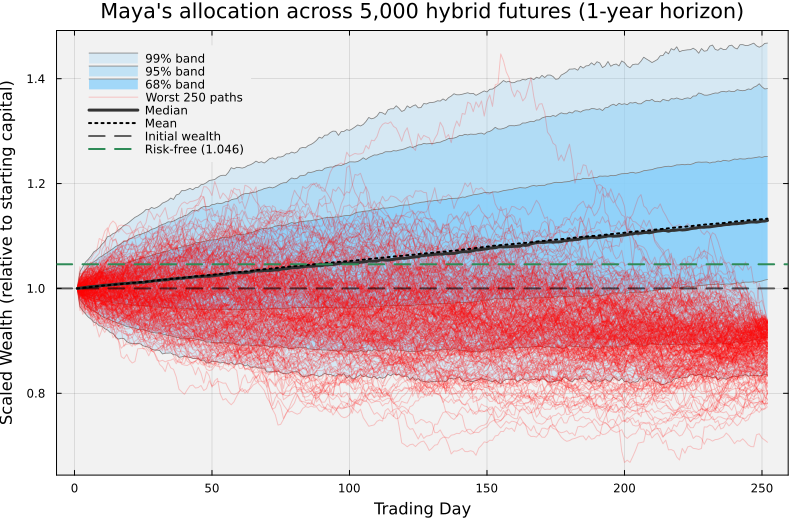

In [14]:
let
    
    # --- Load the cached 5,000-path simulation ---
    cache = load_results(joinpath(_PATH_TO_DATA, "intro-balanced-cones.jld2"));
    W     = cache["wealth_paths"] ./ cache["B_0"];     # (T, n_paths), scaled wealth
    w     = cache["allocation_weights"];
    names = cache["my_tickers"];
    T, n_paths = size(W);
    g_f   = cache["g_f"];

    # --- Sector lookup for the Balanced archetype (from interview.md Step 9) ---
    sector = Dict(
        "DIS"=>"Communication Services", "VZ"=>"Communication Services",
        "AMZN"=>"Consumer Discretionary", "HD"=>"Consumer Discretionary",
        "PG"=>"Consumer Staples", "COST"=>"Consumer Staples",
        "XOM"=>"Energy", "CVX"=>"Energy",
        "JPM"=>"Financials", "V"=>"Financials", "BAC"=>"Financials",
        "JNJ"=>"Health Care", "UNH"=>"Health Care", "LLY"=>"Health Care",
        "HON"=>"Industrials", "CAT"=>"Industrials",
        "AAPL"=>"Information Technology", "MSFT"=>"Information Technology",
        "NVDA"=>"Information Technology",
        "SHW"=>"Materials", "AMT"=>"Real Estate", "NEE"=>"Utilities",
    );

    # --- Empirical quantile cones + worst-5% paths ---
    n_tail    = max(1, floor(Int, 0.05 * n_paths));
    worst_idx = partialsortperm(cache["final_wealth"], 1:n_tail);
    rf_mult   = exp(g_f * (T / 252));
    days      = 1:T;
    q(p)      = [quantile(W[t, :], p) for t ∈ 1:T];
    p005, p025, p160 = q(0.005), q(0.025), q(0.160);
    p840, p975, p995 = q(0.840), q(0.975), q(0.995);
    p500      = [median(W[t, :]) for t ∈ 1:T];
    pmean     = [mean(W[t, :])   for t ∈ 1:T];

    pl = plot(days, p995; fillrange = p005, fillalpha = 0.25, fillcolor = :lightskyblue,
        lw = 0.8, lc = :gray50, label = "99% band",
        xlabel = "Trading Day", ylabel = "Scaled Wealth (relative to starting capital)",
        size = (800, 520), fontsize = 14);
    plot!(pl, days, p005; lw = 0.8, lc = :gray50, label = "");
    plot!(pl, days, p975; fillrange = p025, fillalpha = 0.45, fillcolor = :lightskyblue,
        lw = 0.8, lc = :gray50, label = "95% band");
    plot!(pl, days, p025; lw = 0.8, lc = :gray50, label = "");
    plot!(pl, days, p840; fillrange = p160, fillalpha = 0.75, fillcolor = :lightskyblue,
        lw = 0.8, lc = :gray50, label = "68% band");
    plot!(pl, days, p160; lw = 0.8, lc = :gray50, label = "");
    for (j, idx) ∈ enumerate(worst_idx)
        plot!(pl, days, W[:, idx];
            lw = 1, c = :red, alpha = 0.20,
            label = (j == 1 ? "Worst $(n_tail) paths" : ""));
    end
    plot!(pl, days, p500; lw = 3, c = :gray20, label = "Median");
    plot!(pl, days, pmean; lw = 2, ls = :dot, c = :black, label = "Mean");
    hline!(pl, [1.0]; lw = 2, ls = :dash, c = :black, alpha = 0.6, label = "Initial wealth");
    hline!(pl, [rf_mult]; lw = 2, ls = :dash, c = :seagreen,
        label = "Risk-free ($(round(rf_mult, digits=3)))");
    plot!(pl, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);
    title!(pl, "Maya's allocation across 5,000 hybrid futures (1-year horizon)");
    display(pl);
end;

Let's summarize what this simulation is telling us.

In [ ]:
let

    # Fill me in -
end;

## Three Things Maya Sees

The picture tells a more complicated story than any point estimate would. Even before running the formal stress test, three features of the plot should make Maya hesitate to sign off.

The first is concentration. Two of the twenty-two names in the allocation have hit the twenty-percent cap, and the top four names together hold about three-quarters of the book. That is a mathematical optimum, not a client-facing policy.

The second is the covariance input. The minimum-variance optimizer treated the sample covariance matrix as truth, but a covariance estimated on a ten-year window of twenty-two tickers carries real uncertainty the optimizer has no way to see.

The third is the questionnaire itself. The client answered the risk questions in a calm market, and her stated tolerance may not survive a thirty-percent drawdown, whatever the agent inferred from her answers.

___